In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Drawing Diamonds from a deck

Suppose you have a well shuffled deck of 52 cards, and you draw 10 cards.


-----
### With Replacement (Independence)



This is the easy case, The deck always resets to 13 diamonds and 39 non-diamonds. The probability of getting a diamond is always exactly 25%. Because the deck has no "memory" of previous draws, long streaks of diamonds or long streaks of non-diamonds are entirely possible.

You are watching for success and failure of drawing a diamond, modelled as a binomial, X being the number of diamonds we have $X \text{ follows } Binom(10,\frac{1}{4})$.

$$ E(X) = np = 10*0.25 = 2.5  \\
    Var(X) = np(1-p) = 10*1/4*3/4 = 1.875$$

-----
### Without Replacement (Correlated Draws)


This case demands a little more attention, in fact the deck has what is called "Memory", if you draw a diamond on the first turn, there are now 12 diamonds in a deck of 51 cards, the probability of drawing diamonds changed from 13/52 to 12/51, which is slightly lower, if you somehow draw 5 diamonds, the probability of drawing the 6th is 17%. The deck is actively making the event of drawing diamonds harder.

The probabilities shift to oppose whiever way your luck is running, the final count is continuously nudged back toward the mean, in statistical terms, the individual cards have negative covariance, a success on one draw slightly decreases chances of success on the next draws. This negative covriance shrinks the overall variance of the 10 card draw in comparison with independent draws.


You want to calculate the mean and the variability in the number of Diamonds that appear in the 10 card draw. 

The Variance on the other hand does depend on the covariance between the draws. Since drawing a diamond in effect alters the probability of drawing the next diamonds. The draws are not independent, and the probability is slightly lower each time. This is a hypergeometric distribution.

By setting up indicator variables and by linearity of expectations : 

$$E(X) = 10*\frac{1}{4} = 2.5 \\
  Var(X) = 1.544 \text{ ie } \sigma(X) = 1.242$$

So on average we would expect 2.5 diamonds, and a 95% CI is [0.064, 4.935]

In [ ]:
# Set the parameters for our simulation
n_simulations = 100000
deck_size = 52
diamonds = 13
cards_drawn = 10

# Simulate with replacement (Binomial)
with_replacement = np.random.binomial(n=cards_drawn, p=diamonds/deck_size, size=n_simulations)

# Simulate without replacement (Hypergeometric)
# The deck physically shrinks, changing the probabilities on each draw
without_replacement = np.random.hypergeometric(
    ngood=diamonds, 
    nbad=deck_size - diamonds, 
    nsample=cards_drawn, 
    size=n_simulations
)

# Calculate the empirical variances from the simulated data
var_with = np.var(with_replacement)
var_without = np.var(without_replacement)

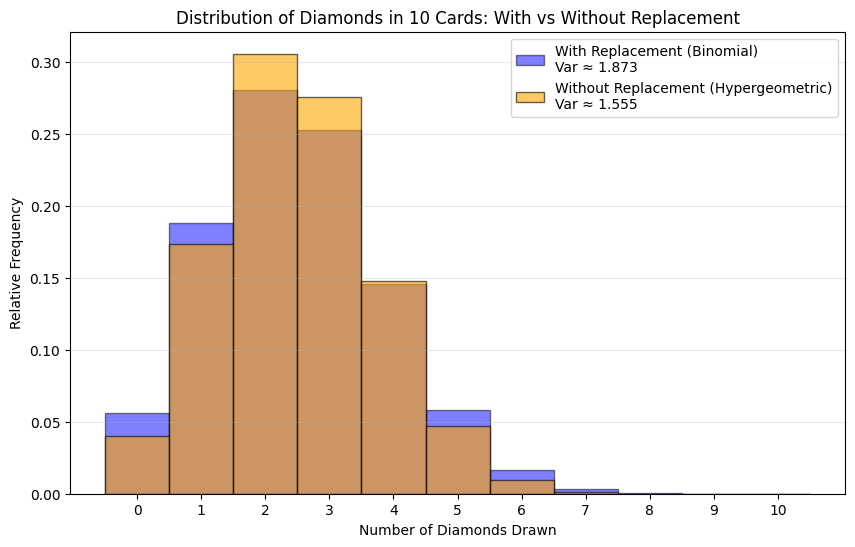

In [7]:
plt.figure(figsize=(10, 6))

bins = np.arange(-0.5, 11.5, 1)

plt.hist(with_replacement, bins=bins, alpha=0.5, 
         label=f'With Replacement (Binomial)\nVar ≈ {var_with:.3f}', 
         density=True, color='blue', edgecolor='black')

plt.hist(without_replacement, bins=bins, alpha=0.6, 
         label=f'Without Replacement (Hypergeometric)\nVar ≈ {var_without:.3f}', 
         density=True, color='orange', edgecolor='black')

plt.title('Distribution of Diamonds in 10 Cards: With vs Without Replacement')
plt.xlabel('Number of Diamonds Drawn')
plt.ylabel('Relative Frequency')
plt.xticks(range(0, 11))
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()